In [53]:
import numpy as np
import tensorflow as tf
import gymnasium as gym
from collections import deque
import random

In [54]:
env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print("State size:", state_size)
print("Action size:", action_size)

State size: 4
Action size: 2


State size: 4
Action size: 2


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,610 (18.01 KB)

 Trainable params: 4,610 (18.01 KB)

 Non-trainable params: 0 (0.00 B)

Episode   1 | Score:  10 | Epsilon: 0.995
Episode   2 | Score:  14 | Epsilon: 0.990
Episode   3 | Score:  11 | Epsilon: 0.985
Episode   4 | Score:  21 | Epsilon: 0.980
Episode   5 | Score:  24 | Epsilon: 0.975
Episode   6 | Score:  14 | Epsilon: 0.970
Episode   7 | Score:  46 | Epsilon: 0.966
Episode   8 | Score:  27 | Epsilon: 0.961
Episode   9 | Score:  48 | Epsilon: 0.956
Episode  10 | Score:  16 | Epsilon: 0.951
Episode  11 | Score:  13 | Epsilon: 0.946
Episode  12 | Score:  11 | Epsilon: 0.942
Episode  13 | Score:  17 | Epsilon: 0.937
Episode  14 | Score:  17 | Epsilon: 0.932
Episode  15 | Score:  10 | Epsilon: 0.928
Episode  16 | Score:  14 | Epsilon: 0.923
Episode  17 | Score:  30 | Epsilon: 0.918
Episode  18 | Score:  37 | Epsilon: 0.914
Episode  19 | Score:  15 | Epsilon: 0.909
Episode  20 | Score:  15 | Epsilon: 0.905
Episode  21 | Score:  23 | Epsilon: 0.900
Episode  22 | Score:  31 | Epsilon: 0.896
Episode  23 | Score:  24 | Epsilon: 0.891
Episode  24 | Score:  27 | Epsilon

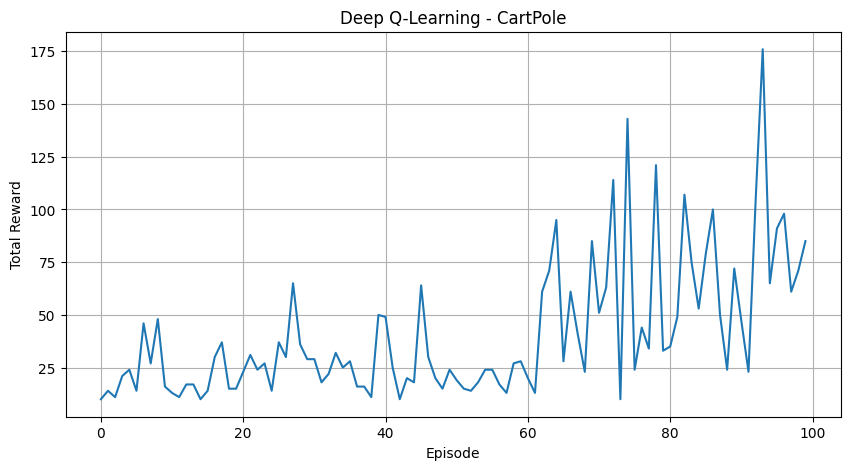

In [56]:
# ============================================================
# 1. Import Libraries
# ============================================================

import numpy as np
import tensorflow as tf
import gymnasium as gym
import random
from collections import deque
import matplotlib.pyplot as plt


# ============================================================
# 2. Create Environment
# ============================================================

env = gym.make("CartPole-v1")

# Get state and action sizes
state_size = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)

print("State size:", state_size)
print("Action size:", action_size)


# ============================================================
# 3. Create Deep Q-Network
# ============================================================

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(state_size,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(action_size, activation="linear")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

model.summary()


# ============================================================
# 4. Replay Memory
# ============================================================

memory = deque(maxlen=2000)


# ============================================================
# 5. Reinforcement Learning Parameters
# ============================================================

gamma = 0.95

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

batch_size = 32


# ============================================================
# 6. Choose Action
# ============================================================

def choose_action(state):

    # Exploration
    if np.random.rand() <= epsilon:
        return random.randrange(action_size)

    # Exploitation
    q_values = model.predict(
        np.expand_dims(state, axis=0),
        verbose=0
    )

    return int(np.argmax(q_values[0]))


# ============================================================
# 7. Train DQN
# ============================================================

def train_model():

    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)

    states = np.array([experience[0] for experience in batch])
    actions = np.array([experience[1] for experience in batch])
    rewards = np.array([experience[2] for experience in batch])
    next_states = np.array(
        [experience[3] for experience in batch]
    )
    dones = np.array([experience[4] for experience in batch])

    # Current Q-values
    current_q = model.predict(
        states,
        verbose=0
    )

    # Next Q-values
    next_q = model.predict(
        next_states,
        verbose=0
    )

    targets = current_q.copy()

    for i in range(batch_size):

        if dones[i]:
            targets[i, actions[i]] = rewards[i]

        else:
            targets[i, actions[i]] = (
                rewards[i]
                + gamma * np.max(next_q[i])
            )

    # Train neural network
    model.fit(
        states,
        targets,
        epochs=1,
        verbose=0
    )


# ============================================================
# 8. Train the Agent
# ============================================================

episodes = 100

scores = []

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0
    done = False

    while not done:

        # Select action
        action = choose_action(state)

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        # Store experience
        memory.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )

        # Update state
        state = next_state

        # Add reward
        total_reward += reward

        # Train model
        train_model()

    # Reduce exploration
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    scores.append(total_reward)

    print(
        f"Episode {episode + 1:3d} | "
        f"Score: {total_reward:3.0f} | "
        f"Epsilon: {epsilon:.3f}"
    )


# ============================================================
# 9. Plot Training Results
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(scores)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Deep Q-Learning - CartPole")

plt.grid(True)

plt.show()


# ============================================================
# 10. Close Environment
# ============================================================

env.close()

In [57]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

In [58]:
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

In [59]:
def choose_action(state):
    if np.random.rand() <= epsilon:
        return random.randrange(action_size)

    q_values = model.predict(
        np.expand_dims(state, axis=0),
        verbose=0
    )

    return np.argmax(q_values[0])

In [60]:
memory = deque(maxlen=2000)

In [61]:
memory.append(
    (state, action, reward, next_state, done)
)

In [62]:
def train_model(batch_size=32):

    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)

    states = np.array([x[0] for x in batch])
    actions = np.array([x[1] for x in batch])
    rewards = np.array([x[2] for x in batch])
    next_states = np.array([x[3] for x in batch])
    dones = np.array([x[4] for x in batch])

    current_q = model.predict(states, verbose=0)
    next_q = model.predict(next_states, verbose=0)

    targets = current_q.copy()

    for i in range(batch_size):

        if dones[i]:
            targets[i, actions[i]] = rewards[i]

        else:
            targets[i, actions[i]] = (
                rewards[i] +
                0.95 * np.max(next_q[i])
            )

    model.fit(
        states,
        targets,
        epochs=1,
        verbose=0
    )

In [63]:
episodes = 100

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

scores = []

for episode in range(episodes):

    state, info = env.reset()
    total_reward = 0
    done = False

    while not done:

        action = choose_action(state)

        next_state, reward, terminated, truncated, info = \
            env.step(action)

        done = terminated or truncated

        memory.append(
            (state, action, reward, next_state, done)
        )

        state = next_state
        total_reward += reward

        train_model()

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    scores.append(total_reward)

    print(
        f"Episode: {episode + 1}, "
        f"Score: {total_reward}, "
        f"Epsilon: {epsilon:.3f}"
    )

Episode: 1, Score: 29.0, Epsilon: 0.995
Episode: 2, Score: 37.0, Epsilon: 0.990
Episode: 3, Score: 12.0, Epsilon: 0.985
Episode: 4, Score: 31.0, Epsilon: 0.980
Episode: 5, Score: 41.0, Epsilon: 0.975
Episode: 6, Score: 40.0, Epsilon: 0.970
Episode: 7, Score: 12.0, Epsilon: 0.966
Episode: 8, Score: 17.0, Epsilon: 0.961
Episode: 9, Score: 11.0, Epsilon: 0.956
Episode: 10, Score: 27.0, Epsilon: 0.951
Episode: 11, Score: 56.0, Epsilon: 0.946
Episode: 12, Score: 15.0, Epsilon: 0.942
Episode: 13, Score: 10.0, Epsilon: 0.937
Episode: 14, Score: 28.0, Epsilon: 0.932
Episode: 15, Score: 21.0, Epsilon: 0.928
Episode: 16, Score: 36.0, Epsilon: 0.923
Episode: 17, Score: 28.0, Epsilon: 0.918
Episode: 18, Score: 22.0, Epsilon: 0.914
Episode: 19, Score: 60.0, Epsilon: 0.909
Episode: 20, Score: 15.0, Epsilon: 0.905
Episode: 21, Score: 18.0, Epsilon: 0.900
Episode: 22, Score: 47.0, Epsilon: 0.896
Episode: 23, Score: 14.0, Epsilon: 0.891
Episode: 24, Score: 33.0, Epsilon: 0.887
Episode: 25, Score: 13.0,

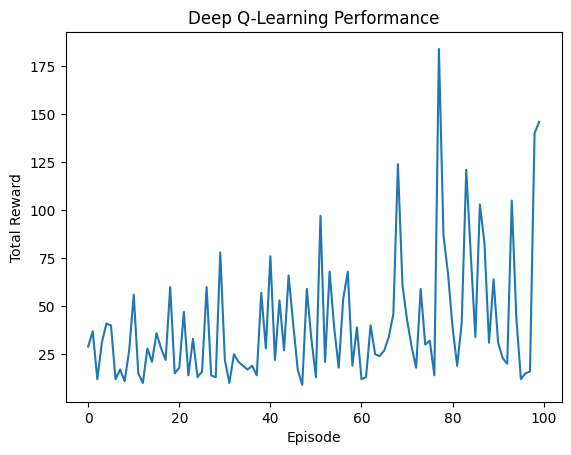

In [64]:
import matplotlib.pyplot as plt

plt.plot(scores)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Deep Q-Learning Performance")
plt.show()